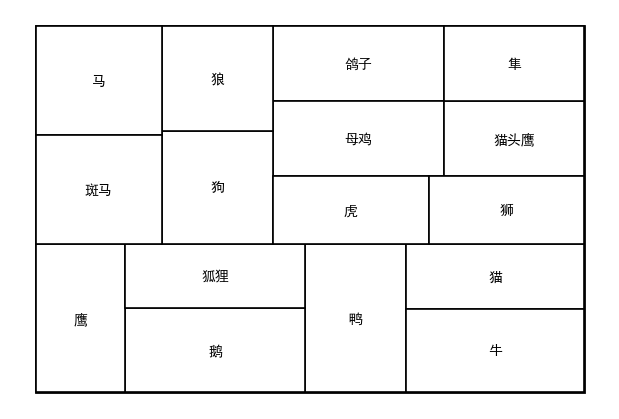

本次训练次数: 11067
随机种子: 3809639416
聚类数量: 6


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import random
from sklearn.neighbors import NearestNeighbors

np.random.seed(random.randint(0,1000))

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['simhei']
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号


# 读取指定的CSV文件
csv_file = "16animals.csv"  # 使用指定的文件名
df = pd.read_csv(csv_file)


# 提取数据（第一列是属性名）
attributes = df.iloc[:, 0].values
animal_names = df.columns[1:].values
features = df.iloc[:, 1:].values.T  # 转置后每行代表一个动物的属性
n_animals = len(animal_names)
features = features.astype(float)

# 标准化特征数据
features = (features - np.mean(features, axis=0)) / (np.std(features, axis=0) + 1e-8)

# 改进的相似度计算（结合余弦相似度和欧氏距离）
def calculate_enhanced_similarity(features):
    n = len(features)
    # 余弦相似度
    cos_sim = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dot_product = np.dot(features[i], features[j])
            norm_i = np.linalg.norm(features[i])
            norm_j = np.linalg.norm(features[j])
            cos_sim[i, j] = dot_product / (norm_i * norm_j + 1e-8)
    
    # 欧氏距离（转换为相似度）
    euclid_dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            euclid_dist[i, j] = np.linalg.norm(features[i] - features[j])
    euclid_sim = 1 / (1 + euclid_dist)  # 距离越小相似度越高
    
    # 融合两种相似度
    return (cos_sim + euclid_sim) / 2

# 优化的SOM实现（带拓扑约束）
class EnhancedSOM:
    def __init__(self, width, height, input_dim, learning_rate=0.2, sigma=2.0):
        self.width = width
        self.height = height
        self.input_dim = input_dim
        self.learning_rate = learning_rate
        self.sigma = sigma
        
        # 初始化权重矩阵（使用更智能的初始化）
        self.weights = np.random.randn(width, height, input_dim) * 0.1
        self.weights += np.mean(features, axis=0)  # 基于数据均值初始化
        
        # 创建神经元坐标和距离矩阵
        self.x = np.arange(width)
        self.y = np.arange(height)
        self.xx, self.yy = np.meshgrid(self.x, self.y, indexing='ij')
        self.neuron_dist = np.sqrt(self.xx**2 + self.yy**2)
        
        # 拓扑约束参数
        self.topology_strength = 0.1  # 控制拓扑结构保持强度

    def find_bmu(self, x):
        # 找到最佳匹配单元
        distances = np.sqrt(np.sum((self.weights - x) **2, axis=2))
        return np.unravel_index(np.argmin(distances), distances.shape)
    
    def update_weights(self, x, bmu, t, max_iter):
        # 学习率和邻域半径衰减
        lr = self.learning_rate * np.exp(-t / max_iter)
        sigma = self.sigma * np.exp(-t / max_iter)
        
        # 计算邻域函数
        dx = self.xx - bmu[0]
        dy = self.yy - bmu[1]
        dist_sq = dx**2 + dy**2
        neighborhood = np.exp(-dist_sq / (2 * sigma**2))
        
        # 应用更新
        weight_update = lr * neighborhood[:, :, np.newaxis] * (x - self.weights)
        self.weights += weight_update
        
        # 拓扑约束：保持神经元之间的空间关系
        if t < max_iter * 0.7:  # 只在训练前期应用
            nn = NearestNeighbors(n_neighbors=3).fit(self.weights.reshape(-1, self.input_dim))
            _, indices = nn.kneighbors(self.weights.reshape(-1, self.input_dim))
            
            for i in range(self.width * self.height):
                nx, ny = np.unravel_index(i, (self.width, self.height))
                for j in indices[i][1:]:  # 跳过自身
                    jx, jy = np.unravel_index(j, (self.width, self.height))
                    # 神经元物理距离
                    phys_dist = np.sqrt((nx - jx)**2 + (ny - jy)** 2)
                    # 权重距离
                    weight_dist = np.linalg.norm(self.weights[nx, ny] - self.weights[jx, jy])
                    # 调整权重以保持距离关系
                    if weight_dist > phys_dist * 1.2:
                        self.weights[jx, jy] += self.topology_strength * (self.weights[nx, ny] - self.weights[jx, jy])
                    elif weight_dist < phys_dist * 0.8:
                        self.weights[jx, jy] -= self.topology_strength * (self.weights[nx, ny] - self.weights[jx, jy])
    
    def train(self, data, max_iter):
        for t in range(max_iter):
            # 按概率选择样本，确保各类别都被充分训练
            prob = np.exp(-t / (max_iter * 0.5)) * 0.5 + 0.5  # 动态调整采样概率
            if np.random.random() < prob:
                # 随机选择
                idx = np.random.randint(data.shape[0])
            else:
                # 基于最近更新时间选择（确保均衡）
                idx = t % data.shape[0]
            x = data[idx]
            bmu = self.find_bmu(x)
            self.update_weights(x, bmu, t, max_iter)
    
    def map_data(self, data):
        mappings = []
        for x in data:
            bmu = self.find_bmu(x)
            # 添加微小随机扰动增加结果多样性
            mappings.append((bmu[0] + np.random.normal(0, 0.1), 
                             bmu[1] + np.random.normal(0, 0.1)))
        return np.array(mappings)

# 计算相似度矩阵
similarity_matrix = calculate_enhanced_similarity(features)

# 计算区域大小
sizes = 1 / (np.sum(similarity_matrix, axis=1) + 1e-8)
sizes = sizes / np.sum(sizes)

# 设置训练参数（增加迭代次数提高稳定性）
train_iterations = random.randint(10000, 15000)  # 每次训练次数随机

# 训练增强版SOM
input_dim = features.shape[1]
som = EnhancedSOM(width=12, height=12, input_dim=input_dim, learning_rate=0.25, sigma=2.5)
som.train(features, max_iter=train_iterations)
mappings = som.map_data(features)

# 改进的聚类算法（自适应密度）
from hdbscan import HDBSCAN
clusterer = HDBSCAN(min_cluster_size=2, min_samples=1)
clusters = clusterer.fit_predict(mappings)

# 优化的递归布局算法（考虑拓扑顺序）
def recursive_rect_layout(sizes, clusters, mappings, x=0, y=0, width=120, height=90):
    if len(sizes) == 1:
        return [{
            'x': x, 'y': y, 
            'width': width, 'height': height,
            'index': 0
        }]
    
    # 优先按聚类分组，聚类相同的放一起
    unique_clusters = np.unique(clusters)
    if len(unique_clusters) > 1 and len(unique_clusters) != len(clusters):
        # 选择最大的聚类作为第一组
        cluster_sizes = {c: np.sum(clusters == c) for c in unique_clusters}
        largest_cluster = max(cluster_sizes, key=cluster_sizes.get)
        mask = clusters == largest_cluster
        group1_sizes = sizes[mask]
        group2_sizes = sizes[~mask]
    else:
        # 按拓扑位置分组（基于SOM映射的x坐标）
        sorted_indices = np.argsort(mappings[:, 0])  # 按x坐标排序
        mid = len(sizes) // 2
        mask = np.zeros_like(sizes, dtype=bool)
        mask[sorted_indices[:mid]] = True
        group1_sizes = sizes[mask]
        group2_sizes = sizes[~mask]
    
    # 计算面积比例
    area1 = np.sum(group1_sizes)
    area2 = np.sum(group2_sizes)
    total_area = area1 + area2
    
    # 智能选择分割方向
    aspect_ratio = width / height
    if aspect_ratio > 1.5:
        # 非常宽，水平分割
        split_x = x + width * (area1 / total_area)
        group1 = recursive_rect_layout(
            group1_sizes, clusters[mask], mappings[mask],
            x, y, split_x - x, height
        )
        group2 = recursive_rect_layout(
            group2_sizes, clusters[~mask], mappings[~mask],
            split_x, y, x + width - split_x, height
        )
    elif aspect_ratio < 0.7:
        # 非常高，垂直分割
        split_y = y + height * (area1 / total_area)
        group1 = recursive_rect_layout(
            group1_sizes, clusters[mask], mappings[mask],
            x, y, width, split_y - y
        )
        group2 = recursive_rect_layout(
            group2_sizes, clusters[~mask], mappings[~mask],
            x, split_y, width, y + height - split_y
        )
    else:
        # 接近正方形，根据组内拓扑分布选择
        if len(group1_sizes) > 0 and len(group2_sizes) > 0:
            group1_range = np.ptp(mappings[mask, 0])  # x方向范围
            group2_range = np.ptp(mappings[~mask, 0])
            if group1_range > group2_range:
                # 第一组x范围大，水平分割
                split_x = x + width * (area1 / total_area)
                group1 = recursive_rect_layout(
                    group1_sizes, clusters[mask], mappings[mask],
                    x, y, split_x - x, height
                )
                group2 = recursive_rect_layout(
                    group2_sizes, clusters[~mask], mappings[~mask],
                    split_x, y, x + width - split_x, height
                )
            else:
                # 垂直分割
                split_y = y + height * (area1 / total_area)
                group1 = recursive_rect_layout(
                    group1_sizes, clusters[mask], mappings[mask],
                    x, y, width, split_y - y
                )
                group2 = recursive_rect_layout(
                    group2_sizes, clusters[~mask], mappings[~mask],
                    x, split_y, width, y + height - split_y
                )
        else:
            #  fallback分割
            split_x = x + width * 0.5
            group1 = recursive_rect_layout(
                group1_sizes, clusters[mask], mappings[mask],
                x, y, split_x - x, height
            )
            group2 = recursive_rect_layout(
                group2_sizes, clusters[~mask], mappings[~mask],
                split_x, y, x + width - split_x, height
            )
    
    # 调整索引
    for rect in group1:
        rect['index'] = np.where(mask)[0][rect['index']]
    for rect in group2:
        rect['index'] = np.where(~mask)[0][rect['index']]
    
    return group1 + group2

# 创建布局
layout = recursive_rect_layout(sizes, clusters, mappings, 0, 0, 60, 40)
layout.sort(key=lambda x: x['index'])

# 创建图形（适应字体大小）
plt.figure(figsize=(6, 4))

# 绘制背景
plt.gca().add_patch(Rectangle((0, 0), 60, 40, facecolor='#f8f8f8', edgecolor='black', linewidth=2))

# 绘制每个动物的矩形区域
for i, rect in enumerate(layout):
    patch = Rectangle(
        (rect['x'], rect['y']), 
        rect['width'], 
        rect['height'],
        facecolor='white', 
        edgecolor='black', 
        linewidth=1.2, 
        alpha=1.0
    )
    plt.gca().add_patch(patch)
    
    # 添加动物名称（20号字体）
    center_x = rect['x'] + rect['width'] / 2
    center_y = rect['y'] + rect['height'] / 2
    # 根据区域大小微调字体，确保适应
    font_size = min(10, max(16, int(rect['width'] / 3), int(rect['height'] / 3)))
    plt.text(center_x, center_y, animal_names[i], 
            fontsize=font_size,
            ha='center', va='center',
            fontweight='bold')

# 设置坐标轴
plt.xlim(0, 60)
plt.ylim(0, 40)
plt.axis('equal')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

# 输出训练信息
print(f"本次训练次数: {train_iterations}")
print(f"随机种子: {np.random.get_state()[1][0]}")
print(f"聚类数量: {len(np.unique(clusters))}")
